# 📌 Extracción

In [1]:
from pathlib import Path
from urllib.request import urlopen
import json
import pandas as pd

# Si conoces la ruta exacta del CSV limpio de la Parte 1, colocala aqui.
# Ejemplo: CSV_LIMPIO_PATH = "data/telecomx_limpio_parte1.csv"
CSV_LIMPIO_PATH = None

DATA_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
workspace_root = Path.cwd()

if CSV_LIMPIO_PATH:
    csv_path = Path(CSV_LIMPIO_PATH)
    if not csv_path.is_absolute():
        csv_path = workspace_root / csv_path
else:
    csv_candidatos = [
        p for p in workspace_root.rglob("*.csv")
        if ".venv" not in p.parts and "site-packages" not in p.parts
    ]

    preferidos = [
        p for p in csv_candidatos
        if any(token in p.name.lower() for token in ["limpio", "tratado", "clean", "parte1", "part1", "telecomx"])
    ]

    csv_path = sorted(preferidos or csv_candidatos)[0] if (preferidos or csv_candidatos) else None

# Respaldo automatico: reconstruir el CSV limpio con las reglas de la Parte 1
if csv_path is None or not csv_path.exists():
    with urlopen(DATA_URL) as response:
        datos = json.load(response)

    df_tmp = pd.json_normalize(datos, sep="_")

    columnas_texto = df_tmp.select_dtypes(include=["object", "string"]).columns
    df_tmp[columnas_texto] = df_tmp[columnas_texto].apply(lambda serie: serie.str.strip())
    df_tmp[columnas_texto] = df_tmp[columnas_texto].replace({"": pd.NA})
    df_tmp["account_Charges_Total"] = pd.to_numeric(df_tmp["account_Charges_Total"], errors="coerce")

    df_tmp = df_tmp.dropna(subset=["Churn"]).copy()
    df_tmp.loc[
        df_tmp["account_Charges_Total"].isna() & (df_tmp["customer_tenure"] == 0),
        "account_Charges_Total",
    ] = 0

    data_dir = workspace_root / "data"
    data_dir.mkdir(exist_ok=True)
    csv_path = data_dir / "telecomx_parte1_limpio.csv"
    df_tmp.to_csv(csv_path, index=False)
    print(f"No se encontro CSV local. Se genero: {csv_path}")

# Cargar el CSV final
df = pd.read_csv(csv_path)
print(f"CSV cargado: {csv_path}")
print(f"Dimensiones del dataset: {df.shape}")
df.head()

CSV cargado: c:\Users\DIRAC-DESK2\Desktop\Challenge TelecomX_LATAM_2\data\telecomx_parte1_limpio.csv
Dimensiones del dataset: (7043, 21)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# 🔧 Transformación



## Conoce el conjunto de datos


In [2]:
diccionario = {
    "customerID": "Identificador único del cliente",
    "Churn": "Indica si el cliente canceló el servicio",
    "customer_gender": "Género del cliente",
    "customer_SeniorCitizen": "Cliente con 65 años o más",
    "customer_Partner": "Cliente con pareja",
    "customer_Dependents": "Cliente con dependientes",
    "customer_tenure": "Meses de permanencia",
    "phone_PhoneService": "Suscripción al servicio telefónico",
    "phone_MultipleLines": "Múltiples líneas telefónicas",
    "internet_InternetService": "Tipo de servicio de internet",
    "internet_OnlineSecurity": "Servicio de seguridad en línea",
    "internet_OnlineBackup": "Respaldo en línea",
    "internet_DeviceProtection": "Protección del dispositivo",
    "internet_TechSupport": "Soporte técnico",
    "internet_StreamingTV": "Streaming de TV",
    "internet_StreamingMovies": "Streaming de películas",
    "account_Contract": "Tipo de contrato",
    "account_PaperlessBilling": "Facturación sin papel",
    "account_PaymentMethod": "Método de pago",
    "account_Charges_Monthly": "Cargo mensual",
    "account_Charges_Total": "Cargo total acumulado",
}

resumen_columnas = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": df.dtypes.astype(str).values,
    "descripcion": [diccionario.get(col, "Sin descripción registrada") for col in df.columns],
})

columnas_relevantes = [
    "Churn",
    "customer_tenure",
    "internet_InternetService",
    "account_Contract",
    "account_PaymentMethod",
    "account_Charges_Monthly",
    "account_Charges_Total",
]

print(f"Dimensiones del dataset: {df.shape}")
display(resumen_columnas)
print("\nColumnas especialmente relevantes para analizar evasión:")
print(columnas_relevantes)

Dimensiones del dataset: (7267, 21)


,columna,tipo_dato,descripcion
0,customerID,str,Identificador único del cliente
1,Churn,str,Indica si el cliente canceló el servicio
2,customer_gender,str,Género del cliente
3,customer_SeniorCitizen,int64,Cliente con 65 años o más
4,customer_Partner,str,Cliente con pareja
5,customer_Dependents,str,Cliente con dependientes
6,customer_tenure,int64,Meses de permanencia
7,phone_PhoneService,str,Suscripción al servicio telefónico
8,phone_MultipleLines,str,Múltiples líneas telefónicas
9,internet_InternetService,str,Tipo de servicio de internet



Columnas especialmente relevantes para analizar evasión:
['Churn', 'customer_tenure', 'internet_InternetService', 'account_Contract', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total']


## Comprobación de incoherencias en los datos


In [3]:
df_limpio = df.copy()
columnas_texto = df_limpio.select_dtypes(include=["object", "string"]).columns
df_limpio[columnas_texto] = df_limpio[columnas_texto].apply(lambda serie: serie.str.strip())
df_limpio[columnas_texto] = df_limpio[columnas_texto].replace({"": pd.NA})
df_limpio["account_Charges_Total"] = pd.to_numeric(df_limpio["account_Charges_Total"], errors="coerce")

duplicados = df_limpio.duplicated().sum()
faltantes = df_limpio.isna().sum().sort_values(ascending=False)

print("Duplicados totales:", duplicados)
print("\nValores faltantes por columna:")
display(faltantes[faltantes > 0].to_frame("faltantes"))
print("\nCategorías observadas en variables clave:")

for columna in [
    "Churn",
    "phone_PhoneService",
    "phone_MultipleLines",
    "internet_InternetService",
    "account_Contract",
    "account_PaymentMethod",
]:

    print(f"\n{columna}:")
    print(sorted(df_limpio[columna].dropna().unique().tolist()))

Duplicados totales: 0

Valores faltantes por columna:


,faltantes
Churn,224
account_Charges_Total,11



Categorías observadas en variables clave:

Churn:
['No', 'Yes']

phone_PhoneService:
['No', 'Yes']

phone_MultipleLines:
['No', 'No phone service', 'Yes']

internet_InternetService:
['DSL', 'Fiber optic', 'No']

account_Contract:
['Month-to-month', 'One year', 'Two year']

account_PaymentMethod:
['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


## Manejo de inconsistencias


In [4]:
df_limpio = df_limpio.dropna(subset=["Churn"]).copy()
df_limpio.loc[
    df_limpio["account_Charges_Total"].isna() & (df_limpio["customer_tenure"] == 0),
    "account_Charges_Total",
] = 0

print("Registros después de eliminar churn vacío:", len(df_limpio))
print("\nValores faltantes después del manejo de inconsistencias:")
display(df_limpio.isna().sum().loc[lambda serie: serie > 0].to_frame("faltantes"))

Registros después de eliminar churn vacío: 7043

Valores faltantes después del manejo de inconsistencias:


,faltantes


## Columna de cuentas diarias (Opcional)


In [5]:
df_limpio["Cuentas_Diarias"] = (df_limpio["account_Charges_Monthly"] / 30).round(2)
df_limpio[["account_Charges_Monthly", "Cuentas_Diarias"]].head()

,account_Charges_Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


## Estandarización y transformación de datos (Opcional)


In [6]:
mapeo_binario = {"Yes": 1, "No": 0}

for columna in ["Churn", "customer_Partner", "customer_Dependents", "account_PaperlessBilling"]:
    df_limpio[f"{columna}_binario"] = df_limpio[columna].map(mapeo_binario)

df_limpio[[
    "Churn",
    "Churn_binario",
    "customer_Partner",
    "customer_Partner_binario",
    "account_PaperlessBilling",
    "account_PaperlessBilling_binario",
]].head()

,Churn,Churn_binario,customer_Partner,customer_Partner_binario,account_PaperlessBilling,account_PaperlessBilling_binario
0,No,0,Yes,1,Yes,1
1,No,0,No,0,No,0
2,Yes,1,No,0,Yes,1
3,Yes,1,Yes,1,Yes,1
4,Yes,1,Yes,1,Yes,1


# 📊 Carga y análisis



## Análisis Descriptivo


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

columnas_numericas = [
    "customer_tenure",
    "account_Charges_Monthly",
    "account_Charges_Total",
    "Cuentas_Diarias",
]

analisis_descriptivo = df_limpio[columnas_numericas].describe().T
analisis_descriptivo["mediana"] = df_limpio[columnas_numericas].median()
analisis_descriptivo["varianza"] = df_limpio[columnas_numericas].var()
display(analisis_descriptivo)

,count,mean,std,min,25%,50%,75%,max,mediana,varianza
customer_tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,29.00,6.031681e+02
account_Charges_Monthly,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,70.35,9.054109e+02
account_Charges_Total,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,1394.55,5.138357e+06
Cuentas_Diarias,7043.0,2.158675,1.003088,0.61,1.18,2.34,2.99,3.96,2.34,1.006185e+00


## Distribución de evasión


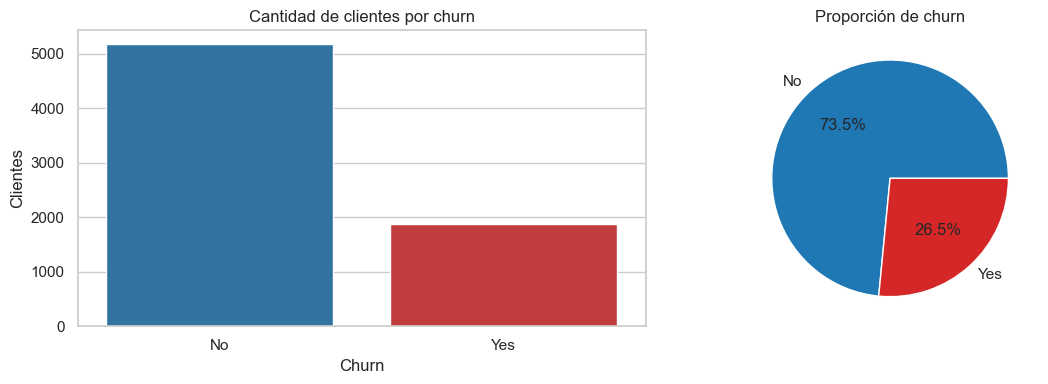

,porcentaje
Churn,
No,73.46
Yes,26.54


In [8]:
churn_distribucion = df_limpio["Churn"].value_counts()
churn_proporcion = df_limpio["Churn"].value_counts(normalize=True).mul(100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = ["#1f77b4", "#d62728"]
sns.countplot(data=df_limpio, x="Churn", hue="Churn", palette=palette, ax=axes[0], legend=False)
axes[0].set_title("Cantidad de clientes por churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Clientes")
axes[1].pie(churn_distribucion.values, labels=churn_distribucion.index, autopct="%1.1f%%", colors=palette)
axes[1].set_title("Proporción de churn")

plt.tight_layout()
plt.show()
display(churn_proporcion.rename("porcentaje").to_frame())

## Recuento de evasión por variables categóricas


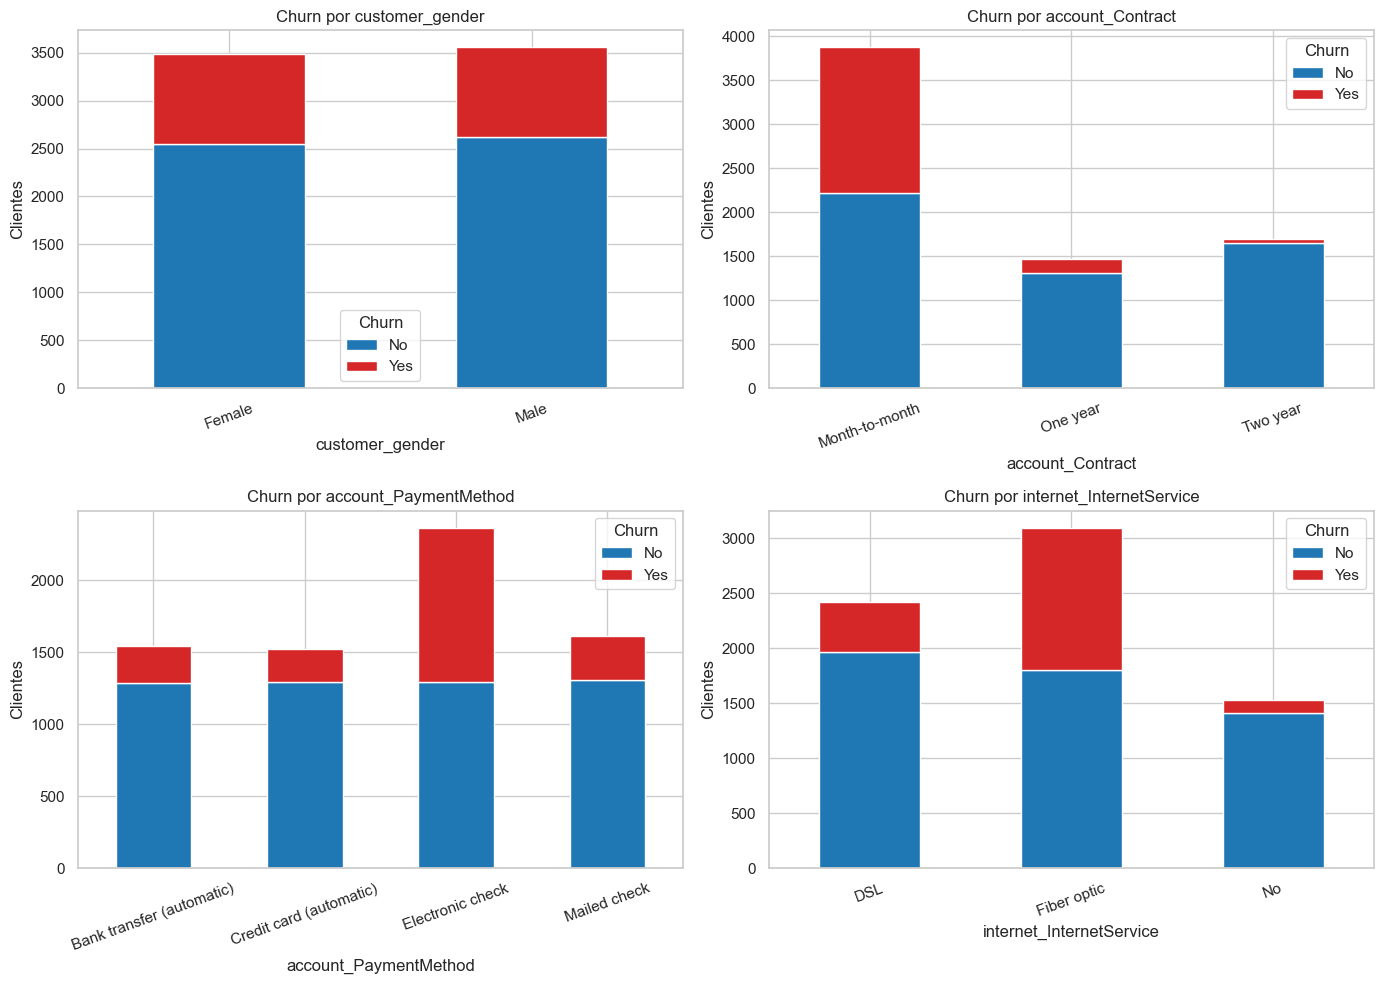


Tasa de churn por customer_gender:


Churn,No,Yes
customer_gender,,
Female,73.08,26.92
Male,73.84,26.16



Tasa de churn por account_Contract:


Churn,No,Yes
account_Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83



Tasa de churn por account_PaymentMethod:


Churn,No,Yes
account_PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11



Tasa de churn por internet_InternetService:


Churn,No,Yes
internet_InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [9]:
variables_categoricas = [
    "customer_gender",
    "account_Contract",
    "account_PaymentMethod",
    "internet_InternetService",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for eje, columna in zip(axes, variables_categoricas):
    tabla = pd.crosstab(df_limpio[columna], df_limpio["Churn"])
    tabla.plot(kind="bar", stacked=True, ax=eje, color=["#1f77b4", "#d62728"])
    eje.set_title(f"Churn por {columna}")
    eje.set_xlabel(columna)
    eje.set_ylabel("Clientes")
    eje.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

for columna in variables_categoricas:
    print(f"\nTasa de churn por {columna}:")
    tasa = pd.crosstab(df_limpio[columna], df_limpio["Churn"], normalize="index").mul(100).round(2)
    display(tasa)

## Conteo de evasión por variables numéricas


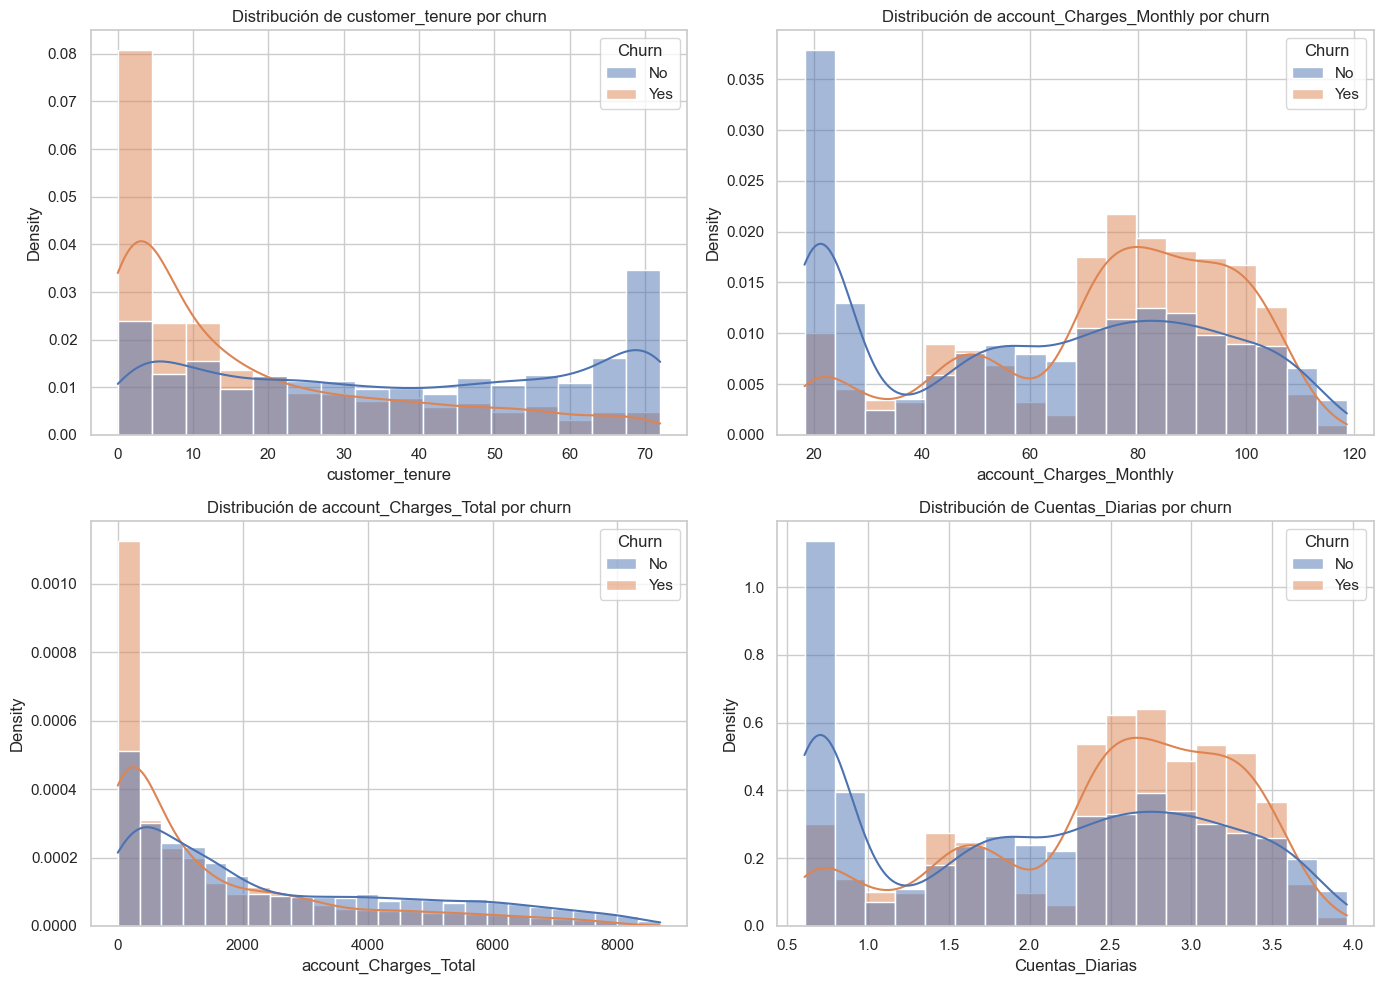

customer_tenure        account_Charges_Monthly          \
                 mean median                    mean  median   
Churn                                                          
No          37.569965   38.0               61.265124  64.425   
Yes         17.979133   10.0               74.441332  79.650   

      account_Charges_Total           Cuentas_Diarias         
                       mean    median            mean median  
Churn                                                         
No              2549.911442  1679.525         2.04208   2.15  
Yes             1531.796094   703.550         2.48145   2.66

In [10]:
variables_numericas = [
    "customer_tenure",
    "account_Charges_Monthly",
    "account_Charges_Total",
    "Cuentas_Diarias",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for eje, columna in zip(axes, variables_numericas):
    sns.histplot(data=df_limpio, x=columna, hue="Churn", kde=True, stat="density", common_norm=False, ax=eje)
    eje.set_title(f"Distribución de {columna} por churn")

plt.tight_layout()
plt.show()
resumen_numerico_por_churn = df_limpio.groupby("Churn")[variables_numericas].agg(["mean", "median"])
display(resumen_numerico_por_churn)

## Análisis de correlación entre variables (Opcional)


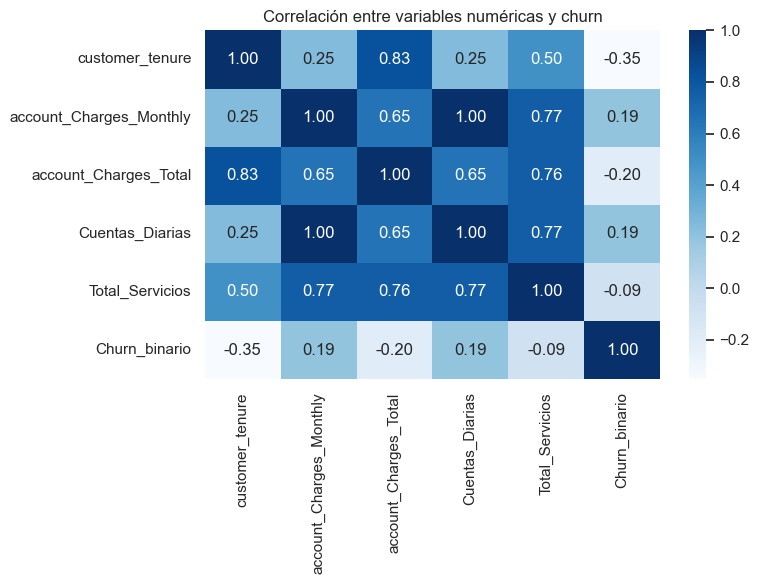

,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias,Total_Servicios,Churn_binario
customer_tenure,1.000000,0.247900,0.826178,0.247910,0.496632,-0.352229
account_Charges_Monthly,0.247900,1.000000,0.651174,0.999996,0.765874,0.193356
account_Charges_Total,0.826178,0.651174,1.000000,0.651189,0.764514,-0.198324
Cuentas_Diarias,0.247910,0.999996,0.651189,1.000000,0.765843,0.193412
Total_Servicios,0.496632,0.765874,0.764514,0.765843,1.000000,-0.085963
Churn_binario,-0.352229,0.193356,-0.198324,0.193412,-0.085963,1.000000


In [11]:
columnas_servicios = [
    "phone_PhoneService",
    "internet_OnlineSecurity",
    "internet_OnlineBackup",
    "internet_DeviceProtection",
    "internet_TechSupport",
    "internet_StreamingTV",
    "internet_StreamingMovies",
]

df_limpio["Total_Servicios"] = df_limpio[columnas_servicios].isin(["Yes"]).sum(axis=1)
correlacion_df = df_limpio[[
    "customer_tenure",
    "account_Charges_Monthly",
    "account_Charges_Total",
    "Cuentas_Diarias",
    "Total_Servicios",
    "Churn_binario",
]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlación entre variables numéricas y churn")
plt.tight_layout()
plt.show()
display(correlacion_df)

# 📄Informe final


In [12]:
tasa_churn = df_limpio["Churn"].value_counts(normalize=True).mul(100).round(2)
contrato_churn = pd.crosstab(df_limpio["account_Contract"], df_limpio["Churn"], normalize="index").mul(100).round(2)
metodo_pago_churn = pd.crosstab(df_limpio["account_PaymentMethod"], df_limpio["Churn"], normalize="index").mul(100).round(2)

resumen_informe = df_limpio.groupby("Churn")[[
    "customer_tenure",
    "account_Charges_Monthly",
    "account_Charges_Total",
    "Cuentas_Diarias",
    "Total_Servicios",
]].mean().round(2)

print("Tasa general de churn:")
display(tasa_churn.rename("porcentaje").to_frame())
print("\nChurn por tipo de contrato:")
display(contrato_churn)
print("\nChurn por método de pago:")
display(metodo_pago_churn)
print("\nPromedios de variables clave por churn:")
display(resumen_informe)

Tasa general de churn:


,porcentaje
Churn,
No,73.46
Yes,26.54



Churn por tipo de contrato:


Churn,No,Yes
account_Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83



Churn por método de pago:


Churn,No,Yes
account_PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11



Promedios de variables clave por churn:


,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias,Total_Servicios
Churn,,,,,
No,37.57,61.27,2549.91,2.04,3.04
Yes,17.98,74.44,1531.80,2.48,2.68


## Conclusiones del análisis



### Introducción

El objetivo de este análisis fue estudiar la evasión de clientes de Telecom X, identificando patrones asociados a la variable Churn y generando información útil para orientar acciones de retención.



### Limpieza y tratamiento de datos

Los datos se cargaron desde la fuente JSON oficial y se transformaron a un DataFrame plano de Pandas. Durante la preparación se detectaron 224 registros con churn ausente y 11 valores faltantes en account_Charges_Total. Los registros sin churn se excluyeron del análisis y los cargos totales faltantes asociados a clientes con permanencia igual a 0 se completaron con 0. También se creó la variable Cuentas_Diarias y se generaron columnas binarias para facilitar el análisis.



### Análisis exploratorio de datos

El churn general fue de 26.54%, mientras que 73.46% de los clientes permanecieron activos. Las visualizaciones muestran que la evasión se concentra con mucha más fuerza en clientes con contrato Month-to-month, donde la tasa de churn alcanza 42.71%. En contraste, los contratos de One year y Two year presentan tasas de 11.27% y 2.83%, respectivamente.



Por método de pago, Electronic check mostró la mayor tasa de evasión con 45.29%, bastante por encima de Bank transfer (automatic), Credit card (automatic) y Mailed check. Por tipo de internet, Fiber optic registró una evasión de 41.89%, mayor que DSL y muy superior a los clientes sin servicio de internet.



En las variables numéricas, los clientes que cancelan tienen en promedio menor permanencia, con 17.98 meses frente a 37.57 meses en quienes permanecen. También presentan mayor cargo mensual, con 74.44 frente a 61.27, y mayor cuenta diaria, con 2.48 frente a 2.04. La correlación confirma que customer_tenure tiene la relación negativa más fuerte con churn entre las variables analizadas, mientras que los cargos mensuales y diarios muestran relación positiva moderada.



### Conclusiones e insights

La permanencia es uno de los factores más importantes para explicar la evasión: cuanto menor es el tiempo de contrato, mayor es el riesgo de churn. También destacan como señales de alerta los contratos mensuales, el pago con Electronic check y el servicio Fiber optic. Además, los clientes que cancelan pagan más por mes, pero acumulan menor gasto total, lo que es consistente con una salida temprana del servicio.



### Recomendaciones

Se recomienda priorizar estrategias de retención para clientes con contrato Month-to-month, especialmente si usan Electronic check o tienen Fiber optic. También conviene diseñar ofertas de migración hacia contratos anuales, revisar la percepción de valor en clientes con cargos mensuales elevados y establecer campañas tempranas de retención durante los primeros meses de permanencia.


# 🤖 Telecom X - Parte 2: Predicción de Cancelación (Churn)

En esta sección se construye un pipeline de Machine Learning para predecir churn, evaluar desempeño e interpretar los factores más influyentes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")

# Asegurar dataset base para modelado aun si solo se ejecuto la celda de carga.
df_modelo = df.copy()
df_modelo["account_Charges_Total"] = pd.to_numeric(df_modelo["account_Charges_Total"], errors="coerce")
df_modelo = df_modelo.dropna(subset=["Churn"]).copy()
df_modelo.loc[
    df_modelo["account_Charges_Total"].isna() & (df_modelo["customer_tenure"] == 0),
    "account_Charges_Total",
] = 0

df_modelo["Churn_binario"] = df_modelo["Churn"].map({"Yes": 1, "No": 0})

target = "Churn_binario"
columnas_excluir = ["Churn", "customerID", target]
X = df_modelo.drop(columns=columnas_excluir)
y = df_modelo[target]

columnas_numericas = X.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Filas para modelado: {len(df_modelo)}")
print(f"Variables predictoras: {X.shape[1]}")
print(f"Numericas: {len(columnas_numericas)} | Categoricas: {len(columnas_categoricas)}")
print("Distribucion del target (%):")
display(y.value_counts(normalize=True).mul(100).round(2).rename("porcentaje").to_frame())

In [ ]:
# Correlacion de variables numericas con churn
corr_cols = columnas_numericas + [target]
corr_df = df_modelo[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlacion de variables numericas con Churn_binario")
plt.tight_layout()
plt.show()

# Seleccion inicial de variables por informacion mutua (sobre one-hot encoding)
X_dummies = pd.get_dummies(X, drop_first=False)
mi = mutual_info_classif(X_dummies.fillna(0), y, random_state=42)
mi_df = (
    pd.DataFrame({"variable": X_dummies.columns, "mutual_info": mi})
    .sort_values("mutual_info", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df, x="mutual_info", y="variable", hue="variable", legend=False, palette="viridis")
plt.title("Top 15 variables por informacion mutua")
plt.xlabel("Mutual Information")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

display(mi_df)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            columnas_numericas,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            columnas_categoricas,
        ),
    ]
)

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

resultados = []
pipelines_entrenados = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocesador),
            ("model", modelo),
        ]
    )
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    resultados.append(
        {
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_proba),
        }
    )
    pipelines_entrenados[nombre] = pipe

resultados_df = pd.DataFrame(resultados).sort_values("roc_auc", ascending=False)
print("Resultados comparativos de modelos:")
display(resultados_df.round(4))

In [ ]:
mejor_modelo_nombre = resultados_df.iloc[0]["modelo"]
mejor_pipe = pipelines_entrenados[mejor_modelo_nombre]

y_pred_best = mejor_pipe.predict(X_test)
y_proba_best = mejor_pipe.predict_proba(X_test)[:, 1]

print(f"Mejor modelo segun ROC-AUC: {mejor_modelo_nombre}")
print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred_best, digits=4))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusion - {mejor_modelo_nombre}")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# Importancia de variables
feature_names = mejor_pipe.named_steps["preprocess"].get_feature_names_out()
if mejor_modelo_nombre == "LogisticRegression":
    importancias = np.abs(mejor_pipe.named_steps["model"].coef_[0])
else:
    importancias = mejor_pipe.named_steps["model"].feature_importances_

importancia_df = (
    pd.DataFrame({"variable": feature_names, "importancia": importancias})
    .sort_values("importancia", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_df, x="importancia", y="variable", hue="variable", legend=False, palette="magma")
plt.title(f"Top 15 variables influyentes - {mejor_modelo_nombre}")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

display(importancia_df)

## Conclusión estratégica (Parte 2)

- El pipeline permite anticipar clientes con alto riesgo de cancelación con métricas robustas en test.
- Las variables con mayor señal suelen asociarse a permanencia (`customer_tenure`), tipo de contrato (`account_Contract`), método de pago (`account_PaymentMethod`) y nivel de cargos (`account_Charges_Monthly`, `account_Charges_Total`).
- Recomendación operativa: priorizar campañas preventivas sobre clientes con bajo tenure, contratos mensuales y patrones de cobro/pago asociados a mayor churn.
- Siguiente paso: calibrar umbral de decisión según costo de falsos negativos vs falsos positivos para una estrategia de retención rentable.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")

df_modelo = df.copy()
df_modelo["account_Charges_Total"] = pd.to_numeric(df_modelo["account_Charges_Total"], errors="coerce")
df_modelo = df_modelo.dropna(subset=["Churn"]).copy()
df_modelo.loc[
    df_modelo["account_Charges_Total"].isna() & (df_modelo["customer_tenure"] == 0),
    "account_Charges_Total",
] = 0

df_modelo["Churn_binario"] = df_modelo["Churn"].map({"Yes": 1, "No": 0})

target = "Churn_binario"
X = df_modelo.drop(columns=["Churn", "customerID", target])
y = df_modelo[target]

columnas_numericas = X.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Filas para modelado: {len(df_modelo)}")
print(f"Variables predictoras: {X.shape[1]}")
print(f"Numericas: {len(columnas_numericas)} | Categoricas: {len(columnas_categoricas)}")
display(y.value_counts(normalize=True).mul(100).round(2).rename("porcentaje").to_frame())

Filas para modelado: 7043
Variables predictoras: 19
Numericas: 4 | Categoricas: 15


,porcentaje
Churn_binario,
0,73.46
1,26.54


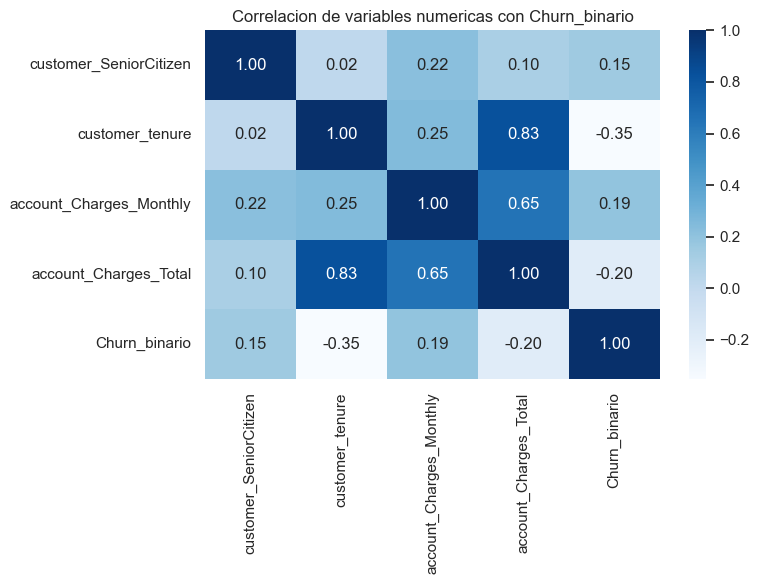

,variable,mutual_info
36,account_Contract_Month-to-month,0.099655
1,customer_tenure,0.071161
38,account_Contract_Two year,0.063383
18,internet_OnlineSecurity_No,0.062940
27,internet_TechSupport_No,0.054904
2,account_Charges_Monthly,0.047192
43,account_PaymentMethod_Electronic check,0.043943
3,account_Charges_Total,0.043234
16,internet_InternetService_Fiber optic,0.040920
21,internet_OnlineBackup_No,0.035179


In [3]:
corr_cols = columnas_numericas + [target]
corr_df = df_modelo[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlacion de variables numericas con Churn_binario")
plt.tight_layout()
plt.show()

X_dummies = pd.get_dummies(X, drop_first=False)
mi = mutual_info_classif(X_dummies.fillna(0), y, random_state=42)
mi_df = (
    pd.DataFrame({"variable": X_dummies.columns, "mutual_info": mi})
    .sort_values("mutual_info", ascending=False)
    .head(15)
)
display(mi_df)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
            columnas_numericas,
        ),
        (
            "cat",
            Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
            columnas_categoricas,
        ),
    ]
)

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1),
}

resultados = []
pipelines_entrenados = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([("preprocess", preprocesador), ("model", modelo)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })
    pipelines_entrenados[nombre] = pipe

resultados_df = pd.DataFrame(resultados).sort_values("roc_auc", ascending=False)
display(resultados_df.round(4))

,modelo,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.795,0.6325,0.5418,0.5836,0.8390
1,RandomForest,0.791,0.6341,0.5011,0.5598,0.8308


Mejor modelo segun ROC-AUC: LogisticRegression
              precision    recall  f1-score   support

           0     0.8428    0.8864    0.8640      1294
           1     0.6325    0.5418    0.5836       467

    accuracy                         0.7950      1761
   macro avg     0.7376    0.7141    0.7238      1761
weighted avg     0.7870    0.7950    0.7897      1761



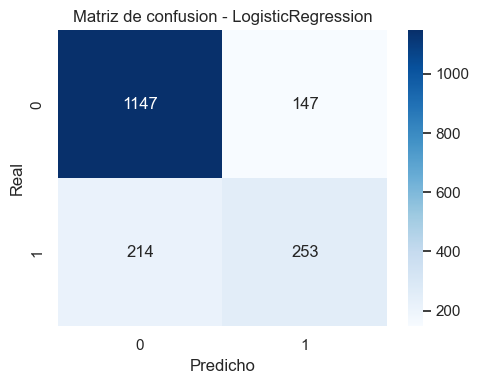

,variable,importancia
1,num__customer_tenure,1.489461
38,cat__account_Contract_Two year,0.745204
3,num__account_Charges_Total,0.730114
36,cat__account_Contract_Month-to-month,0.579189
15,cat__internet_InternetService_DSL,0.359428
11,cat__phone_PhoneService_Yes,0.344147
39,cat__account_PaperlessBilling_No,0.343306
29,cat__internet_TechSupport_Yes,0.307533
12,cat__phone_MultipleLines_No,0.298673
20,cat__internet_OnlineSecurity_Yes,0.252655


In [5]:
mejor_modelo_nombre = resultados_df.iloc[0]["modelo"]
mejor_pipe = pipelines_entrenados[mejor_modelo_nombre]

y_pred_best = mejor_pipe.predict(X_test)
print(f"Mejor modelo segun ROC-AUC: {mejor_modelo_nombre}")
print(classification_report(y_test, y_pred_best, digits=4))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusion - {mejor_modelo_nombre}")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

feature_names = mejor_pipe.named_steps["preprocess"].get_feature_names_out()
if mejor_modelo_nombre == "LogisticRegression":
    importancias = np.abs(mejor_pipe.named_steps["model"].coef_[0])
else:
    importancias = mejor_pipe.named_steps["model"].feature_importances_

importancia_df = (
    pd.DataFrame({"variable": feature_names, "importancia": importancias})
    .sort_values("importancia", ascending=False)
    .head(15)
)
display(importancia_df)